
# RNN vs LSTM vs GRU

## Instructions

In this lab, you will build **three text classification models** from scratch:
- RNN
- LSTM
- GRU

---

### Objectives
By the end of this lab, you should be able to:

- Preprocess text data
- Build a vocabulary
- Encode and pad sequences
- Implement RNN, LSTM, and GRU in PyTorch
- Train and evaluate models 
- Compare architectures


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split
from datasets import load_dataset

from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [2]:
label_map = {
    "Human": 0,
    "Anthropic": 1,
    "Google": 2,
    "OpenAI": 3,
    "Meta": 4
}

In [ ]:
# data loading
dataset = load_dataset("csv", data_files="../dataset-exemplos.csv")

dataset = dataset["train"].train_test_split(test_size=0.2)

train_data = list(dataset["train"])
test_data = list(dataset["test"])

# remove exemples without labels
train_data = [x for x in train_data if x["Label"] is not None]
test_data = [x for x in test_data if x["Label"] is not None]

print("Train size:", len(train_data))
print("Test size:", len(test_data))

Train size: 99
Test size: 26


In [4]:
print(dataset["train"].features)
print(train_data[0])

{'ID': Value('large_string'), 'Text': Value('large_string'), 'Label': Value('large_string')}
{'ID': 'D1-66', 'Text': 'Molecular data on relationships within angiosperms confirm the view that their increasing morphological diversity through the Cretaceous reflected their evolutionary radiation. Despite the early appearance of aquatics and groups with simple flowers, the record is consistent with inferences from molecular trees that the first angiosperms were woody plants with pinnately veined leaves, multiparted flowers, uniovulate ascidiate carpels, and columellar monosulcate pollen. Molecular data appear to refute the hypothesis based on morphology that angiosperms and Gnetales are closest living relatives. Morphological analyses of living and fossil seed plants that assume molecular relationships identify glossopterids, Bennettitales, and Caytonia as angiosperm relatives, these results are consistent with proposed homologies between the cupule of glossopterids and Caytonia and the an

In [5]:
sum(1 for x in train_data if x["Label"] is None)

0

In [6]:
train_texts = [x["Text"] for x in train_data]
test_texts = [x["Text"] for x in test_data]

train_labels = [label_map[x["Label"].strip()] for x in train_data]
test_labels = [label_map[x["Label"].strip()] for x in test_data]


# Part 1 – Text Preprocessing

You must:

1. Write a `tokenize(text)` function.
2. Build a vocabulary using the training set only.
3. Keep only the top 10,000 most frequent words.
4. Add special tokens:
   - `<pad>`
   - `<unk>`
5. Explain in a markdown cell:
   - Why do we not build the vocabulary using the test set?


In [7]:
import re

def tokenize(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-zA-Z]", " ", text)
    return text.split()

In [8]:
tokenize(train_data)

['id',
 'd',
 'text',
 'molecular',
 'data',
 'on',
 'relationships',
 'within',
 'angiosperms',
 'confirm',
 'the',
 'view',
 'that',
 'their',
 'increasing',
 'morphological',
 'diversity',
 'through',
 'the',
 'cretaceous',
 'reflected',
 'their',
 'evolutionary',
 'radiation',
 'despite',
 'the',
 'early',
 'appearance',
 'of',
 'aquatics',
 'and',
 'groups',
 'with',
 'simple',
 'flowers',
 'the',
 'record',
 'is',
 'consistent',
 'with',
 'inferences',
 'from',
 'molecular',
 'trees',
 'that',
 'the',
 'first',
 'angiosperms',
 'were',
 'woody',
 'plants',
 'with',
 'pinnately',
 'veined',
 'leaves',
 'multiparted',
 'flowers',
 'uniovulate',
 'ascidiate',
 'carpels',
 'and',
 'columellar',
 'monosulcate',
 'pollen',
 'molecular',
 'data',
 'appear',
 'to',
 'refute',
 'the',
 'hypothesis',
 'based',
 'on',
 'morphology',
 'that',
 'angiosperms',
 'and',
 'gnetales',
 'are',
 'closest',
 'living',
 'relatives',
 'morphological',
 'analyses',
 'of',
 'living',
 'and',
 'fossil',
 

In [9]:
from collections import Counter

def build_vocab(texts, max_words=10000):

    counter = Counter()

    for text in texts:

        if text is None:
            continue

        tokens = tokenize(text)
        counter.update(tokens)

    most_common = counter.most_common(max_words)

    vocab = {
        "<pad>": 0,
        "<unk>": 1
    }

    for word, _ in most_common:
        vocab[word] = len(vocab)

    return vocab

In [10]:
vocab = build_vocab(train_texts)


# Part 2 – Encoding and Padding

You must:

1. Create an `encode(text)` function.
2. Convert tokens into vocabulary indices.
3. Pad or truncate sequences to a fixed length (e.g., 25).
4. Create a custom `collate()` function.
5. Create train, validation, and test DataLoaders.

Explain:
- Why is padding necessary?
- Why should validation and test loaders not shuffle?


In [11]:
def encode(vocab, text, max_len=25):
    tokens = tokenize(text)

    ids = [vocab.get(token, vocab["<unk>"]) for token in tokens]

    if len(ids) < max_len:
        ids += [vocab["<pad>"]] * (max_len - len(ids))
    else:
        ids = ids[:max_len]

    return ids

In [12]:
def one_hot_encode(vocab, token):
    vector = np.zeros(len(vocab))
    
    token_index = vocab.get(token, vocab["<unk>"])
    vector[token_index] = 1
    
    return vector

In [13]:
train_loader = DataLoader(
    dataset["train"],
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    dataset["test"],
    batch_size=32,
    shuffle=False
)


# Part 3 – Model Implementation

Create a class called `Model` that:

- Uses an Embedding layer
- Supports:
  - RNN
  - LSTM
  - GRU
- Uses multiple layers
- Applies dropout
- Outputs class logits

Your model must accept:
- model_type
- vocab_size
- embed_dim
- hidden_dim
- num_layers

Explain:
- The internal difference between RNN, LSTM, and GRU.


In [14]:
class Model(nn.Module):
    def __init__(self, model_type, vocab_size, embed_dim, hidden_dim, num_layers, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.dropout = nn.Dropout(dropout)

        if model_type == "RNN":
            self.rnn = nn.RNN(embed_dim, hidden_dim, num_layers, batch_first=True)
        elif model_type == "LSTM":
            self.rnn = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True)
        else:
            self.rnn = nn.GRU(embed_dim, hidden_dim, num_layers, batch_first=True)

        self.fc = nn.Linear(hidden_dim, 4)

        def forward(self, x):
            x = self.embedding(x)
            x = self.drpout(x)
            out, h = self.rnn(x)
            if isinstance(h, tuple):
                h = h[0]
                return self.fc(h[-1])


# Part 4 – Training Loop

Implement:

- A full training loop
- Validation loop
- Accuracy computation
- Loss tracking per epoch

Train for 10-50 epochs.

Store:
- train_loss
- val_loss
- train_accuracy
- val_accuracy

Explain:
- Why do we use `model.train()` and `model.eval()`?


In [15]:
def train(model, train_loader, val_loader, criterion, epochs = 10, lr = 0.001, verbose = True):
    ## verbose - print losses and accuracies per epoch
    
    train_accs = []
    val_accs = []
    train_losses = []
    val_losses = []
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    
    for epoch in range(epochs): 
        model.train()
        for x, y in train_loader:
            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()

        train_loss, train_acc = evaluate(model, train_loader, criterion)
        val_loss, val_acc = evaluate(model, val_loader, criterion)
        
        train_accs.append(train_acc)
        train_losses.append(train_loss)
        val_accs.append(val_acc)
        val_losses.append(val_loss)

        if verbose: 
            print(f"Epoch {epoch+1}")
            print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
            print(f"Val   Loss: {val_loss:.4f}, Val   Acc: {val_acc:.4f}")
    
    return train_accs, val_accs, train_losses, val_losses


# Part 5 – Model Comparison

Train:
- RNN
- LSTM
- GRU

Track validation accuracy and determine:
- Which performs best?
- Why?

Plot:
- Loss curves
- Accuracy curves

Explain signs of overfitting.


In [16]:
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            outputs = model(x)
            loss = criterion(outputs, y)
            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return total_loss / len(loader), correct / total

In [17]:
def plot_values(list_values, list_labels  = ["Train", "Validation"], ylabel = "Accuracy", title = None):
    plt.figure()
    for i in range(len(list_values)):
        plt.plot(list_values[i], label = list_labels[i])
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.legend()
    if title is not None: plt.title()
    plt.show()

In [ ]:
def load_dataset_embed(filespath, max_words, max_len=100, batch_size=32):

    dataset = load_dataset("csv", data_files="../dataset-exemplos.csv")

    dataset = dataset["train"].train_test_split(test_size=0.2)

    train_data = dataset["train"]
    test_data = dataset["test"]

    train_texts = [x["Text"] for x in train_data]
    train_labels = [x["Label"] for x in train_data]

    test_texts = [x["Text"] for x in test_data]
    test_labels = [x["Label"] for x in test_data]

    vocab = build_vocab(train_texts, max_words)

    def collate(batch):
        texts = [x["Text"] for x in batch if x["Label"] is not None]
        labels = [
            label_map[x["Label"].strip()]
            for x in batch
            if x["Label"] is not None
        ]
    
        encoded = [encode(vocab, t, max_len) for t in texts]
    
        x = torch.tensor(encoded, dtype=torch.long)
        y = torch.tensor(labels, dtype=torch.long)
        return x.to(device), y.to(device)

    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, collate_fn=collate)

    val_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, collate_fn=collate)

    test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, collate_fn=collate)

    return train_loader, val_loader, test_loader

In [35]:
class RNNClassifier(nn.Module):

    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.RNN(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim, 5)

    def forward(self, x):
        embedded = self.embedding(x)
        output, hidden = self.rnn(embedded)
        last_hidden = hidden[-1]
        out = self.fc(last_hidden)
        return out

In [43]:
class LSTMClassifier(nn.Module):

    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=1, dropout=0.0, bidirectional=False, num_classes=5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.dropout = nn.Dropout(dropout)
        direction_factor = 2 if bidirectional else 1
        self.fc = nn.Linear(hidden_dim * direction_factor, num_classes)

    def forward(self, x):
        # x: (batch_size, seq_len)
        embedded = self.embedding(x)     # (B, L, E)
        output, (hidden, cell) = self.lstm(embedded)

        if self.lstm.bidirectional:
            forward_hidden = hidden[-2]
            backward_hidden = hidden[-1]
            last_hidden = torch.cat((forward_hidden, backward_hidden), dim=1)
        else:
            last_hidden = hidden[-1]

        last_hidden = self.dropout(last_hidden)

        out = self.fc(last_hidden)

        return out   # (B, num_classes)

In [44]:
class GRUClassifier(nn.Module):

    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=1, dropout=0.0, bidirectional=False, num_classes=5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.gru = nn.GRU(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.dropout = nn.Dropout(dropout)
        direction_factor = 2 if bidirectional else 1
        self.fc = nn.Linear(hidden_dim * direction_factor, num_classes)

    def forward(self, x):
        # x: (batch_size, seq_len)
        embedded = self.embedding(x)
        output, hidden = self.gru(embedded)

        if self.gru.bidirectional:
            forward_hidden = hidden[-2]
            backward_hidden = hidden[-1]
            last_hidden = torch.cat((forward_hidden, backward_hidden), dim=1)
        else:
            last_hidden = hidden[-1]
        last_hidden = self.dropout(last_hidden)
        out = self.fc(last_hidden)
        return out   # (B, num_classes)

In [ ]:
def test_rnn():
    filespath = "../dataset-exemplos.csv"
    max_words = 20000
    max_len = 100
    embed_dim = 200
    train_loader, val_loader, test_loader = load_dataset_embed(filespath, max_words, max_len = max_len)
    model = RNNClassifier(max_words,embed_dim, hidden_dim=128, num_layers=1)
    criterion = nn.CrossEntropyLoss()
    train_accs, val_accs, train_losses, val_losses = train(model, train_loader, val_loader, criterion, epochs = 20)

    plot_values([train_accs, val_accs])
    plot_values([train_losses, val_losses], ylabel = "Loss")
    
    _, test_acc = evaluate(model, test_loader, criterion)
    print(f"Test Accuracy: {test_acc:.4f}")
    confusion_matrix_eval(model, test_loader)

def test_lstm():
    filespath = "../dataset-exemplos.csv"
    max_words = 20000
    max_len = 100 ## do not increase
    embed_dim = 200
    train_loader, val_loader, test_loader = load_dataset_embed(filespath, max_words, max_len = max_len)
    model = LSTMClassifier(max_words,embed_dim, hidden_dim=128, num_layers=2, bidirectional = True, dropout = 0.5)
    criterion = nn.CrossEntropyLoss()
    train_accs, val_accs, train_losses, val_losses = train(model, train_loader, val_loader, criterion, epochs = 20) #, lr = 0.0001)

    plot_values([train_accs, val_accs])
    plot_values([train_losses, val_losses], ylabel = "Loss")
    
    _, test_acc = evaluate(model, test_loader, criterion)
    print(f"Test Accuracy: {test_acc:.4f}")
    confusion_matrix_eval(model, test_loader)

def test_gru():
    filespath = "../dataset-exemplos.csv"
    max_words = 20000
    max_len = 100 ## do not increase
    embed_dim = 200
    train_loader, val_loader, test_loader = load_dataset_embed(filespath, max_words, max_len = max_len)
    model = GRUClassifier(max_words,embed_dim, hidden_dim=128, num_layers=1, bidirectional = True, dropout = 0.3)
    criterion = nn.CrossEntropyLoss()
    train_accs, val_accs, train_losses, val_losses = train(model, train_loader, val_loader, criterion, epochs = 20) #, lr = 0.0001)
    
    plot_values([train_accs, val_accs])
    plot_values([train_losses, val_losses], ylabel = "Loss")
    
    _, test_acc = evaluate(model, test_loader, criterion)
    print(f"Test Accuracy: {test_acc:.4f}")
    confusion_matrix_eval(model, test_loader)


# Part 6 – Final Evaluation

Using the best model:

1. Evaluate on the test set.
2. Compute test accuracy.
3. Plot a confusion matrix.

Explain:
- Which classes are most confused?
- Why might that happen?


In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def confusion_matrix_eval(model, loader):

    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x, y in loader:

            outputs = model(x)

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)

    disp = ConfusionMatrixDisplay(cm)
    disp.plot()

Epoch 1
Train Loss: 1.5662, Train Acc: 0.5152
Val   Loss: 1.5838, Val   Acc: 0.4615
Epoch 2
Train Loss: 1.5097, Train Acc: 0.5051
Val   Loss: 1.5504, Val   Acc: 0.5769
Epoch 3
Train Loss: 1.4918, Train Acc: 0.4141
Val   Loss: 1.5073, Val   Acc: 0.5000
Epoch 4
Train Loss: 1.4139, Train Acc: 0.3939
Val   Loss: 1.4438, Val   Acc: 0.5000
Epoch 5
Train Loss: 1.4246, Train Acc: 0.3939
Val   Loss: 1.3680, Val   Acc: 0.5000
Epoch 6
Train Loss: 1.3372, Train Acc: 0.3939
Val   Loss: 1.3411, Val   Acc: 0.5000
Epoch 7
Train Loss: 1.2488, Train Acc: 0.4444
Val   Loss: 1.3398, Val   Acc: 0.5000
Epoch 8
Train Loss: 0.9434, Train Acc: 0.6768
Val   Loss: 1.3836, Val   Acc: 0.4615
Epoch 9
Train Loss: 0.8573, Train Acc: 0.7374
Val   Loss: 1.3173, Val   Acc: 0.5000
Epoch 10
Train Loss: 0.8341, Train Acc: 0.8182
Val   Loss: 1.2591, Val   Acc: 0.5385
Epoch 11
Train Loss: 0.7060, Train Acc: 0.8889
Val   Loss: 1.2709, Val   Acc: 0.5385
Epoch 12
Train Loss: 0.5763, Train Acc: 0.9596
Val   Loss: 1.2420, Val   A

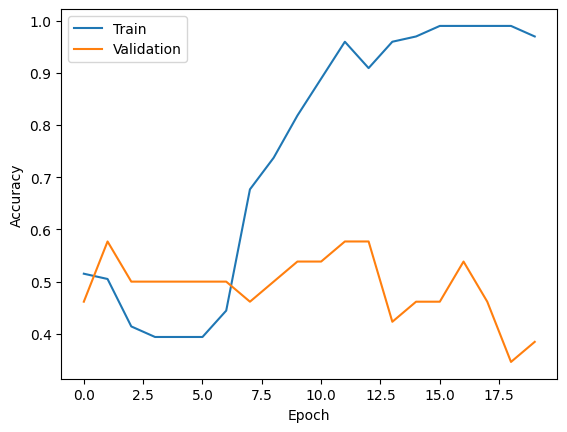

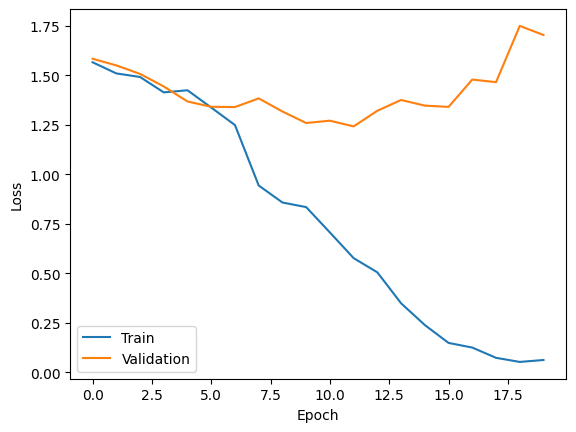

Test Accuracy: 0.3846


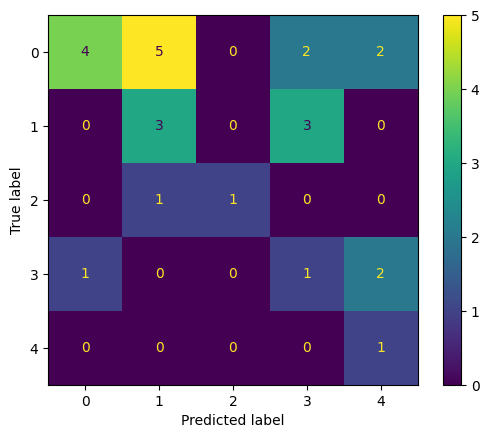

In [50]:
#test_rnn()
test_lstm()
#test_gru()